## **Wordstat_top_queries**

In [19]:
import csv
import io
from pathlib import Path



csv_path = Path("/Users/macbook/Desktop/pythonProject/wordstat_top_queries.csv")

#read csv and erase byte order mark UTF-8 файла (EF BB BF)
text = csv_path.read_text(encoding="utf-8-sig")
text = text.replace("\r\n", "\n")

#parse csv with spliter
reader = csv.DictReader(io.StringIO(text), delimiter=";")
fields = reader.fieldnames #take first row of csv and save it as a list
print('Columns:', fields)

'''
import itertools

print(type(reader))
print("fieldnames:", reader.fieldnames)

for row in itertools.islice(reader, 3):
    print(row)
'''

#According to csv
query_col = fields[0]
count_col = fields[1]
meta_col = fields[2]

#Make numbers "readable" from 2 834 650 to 2834650
def to_int(s):
  return int(s.replace(" ", "").replace("\u00a0", "").replace("\u202f", "").strip())

#prepare Tab-Separated Values for ClickHouse
rows = []
for row in reader:
  q = (row.get(query_col)).strip()
  count = to_int(row.get(count_col))
  meta = (row.get(meta_col)).strip()
  rows.append(f"{q}\t{count}\t{meta}")
payload = '\n'.join(rows)
#print(payload)

#Load into GoogleDrive
out_path = Path("/Users/macbook/Desktop/pythonProject/dynamic_clean.tsv")
out_path.write_text(payload, encoding="utf-8")
print("Saved:", out_path, "rows:", len(rows))



Columns: ['Формулировка', 'Число запросов', 'Топ частотных запросов «кроссовки», 17.01.2026 — 17.02.2026, все регионы, все устройства']
Saved: /Users/macbook/Desktop/pythonProject/dynamic_clean.tsv rows: 2000


In [20]:
#Load into ClickHouse using Bash
#clickhouse client --query "INSERT INTO wordstat.dynamic_raw (period_raw, period_date, requests, share_pct, dataset_meta) FORMAT TSV" < "/Users/macbook/Desktop/pythonProject/dynamic_clean.tsv"
#clickhouse client --query "SELECT count() FROM wordstat.dynamic_raw"


Load into ClickHouse using Bash

1.   *clickhouse client --query "INSERT INTO wordstat.dynamic_raw (period_raw, period_date, requests, share_pct, dataset_meta) FORMAT TSV" < "/Users/macbook/Desktop/pythonProject/dynamic_clean.tsv"*
2.   *clickhouse client --query "SELECT count() FROM wordstat.dynamic_raw"*

## **Wordstat_Dynamic**


In [21]:
import io
import csv
from pathlib import Path
from datetime import datetime

csv_path = Path("/Users/macbook/Desktop/pythonProject/wordstat_dynamic.csv")
text = csv_path.read_text(encoding = "utf-8-sig").replace("\r\n", "\n")
reader = csv.DictReader(io.StringIO(text), delimiter = ";")
fields = reader.fieldnames
print('Columns: ', fields)

period_col = fields[0]
count_query_col = fields[1]
share_col = fields[2]
meta_col = fields[3]

months = {
    "январь": 1, "февраль": 2, "март": 3, "апрель": 4, "май": 5, "июнь": 6,
    "июль": 7, "август": 8, "сентябрь": 9, "октябрь": 10, "ноябрь": 11, "декабрь": 12
}

def to_int(s):
  return int(s.replace(" ", "").replace("\u00a0", "").replace("\u202f", "").strip())

def to_float(s):
  return float(s.replace(" ", "").replace("\u00a0", "").replace("\u202f", "").replace(",", ".").strip())

def period_to_date(s):
  #февраль 2024 = 2024-02-01, strftime = string format time
  parts = str(s).strip().lower().split()
  month = months[parts[0]]
  year = int(parts[1])
  return datetime(year, month, 1).strftime("%Y-%m-%d")

rows = []
for row in reader:
  period = period_to_date(row.get(period_col))
  count = to_int(row.get(count_query_col))
  share = to_float(row.get(share_col))
  meta = (row.get(meta_col)).strip()
  rows.append(f"{period}\t{count}\t{share}\t{meta}")

payload = '\n'.join(rows)
out_path = Path("/Users/macbook/Desktop/pythonProject/dynamic_clean.tsv")
out_path.write_text(payload, encoding="utf-8")
print(rows[:3])
print("Saved:", out_path, "rows:", len(rows))



Columns:  ['Период', 'Число запросов', 'Доля от всех запросов, %', 'Динамика частотности запросов «кроссовки», по месяцам, 01.02.2024 — 31.01.2026, все регионы, все устройства']
['2024-02-01\t2895024\t0.025\t', '2024-03-01\t4359585\t0.037\t', '2024-04-01\t5006077\t0.046\t']
Saved: /Users/macbook/Desktop/pythonProject/dynamic_clean.tsv rows: 24


## Load into ClickHouse using Bash

1.   clickhouse client --query "INSERT INTO wordstat.dynamic_raw (period_date, requests, share_pct, dataset_meta) FORMAT TSV" < "/Users/macbook/Desktop/pythonProject/dynamic_clean.tsv"
2.   clickhouse client --query "SELECT count() FROM wordstat.dynamic_raw"



clickhouse bin: /opt/homebrew/bin/clickhouse


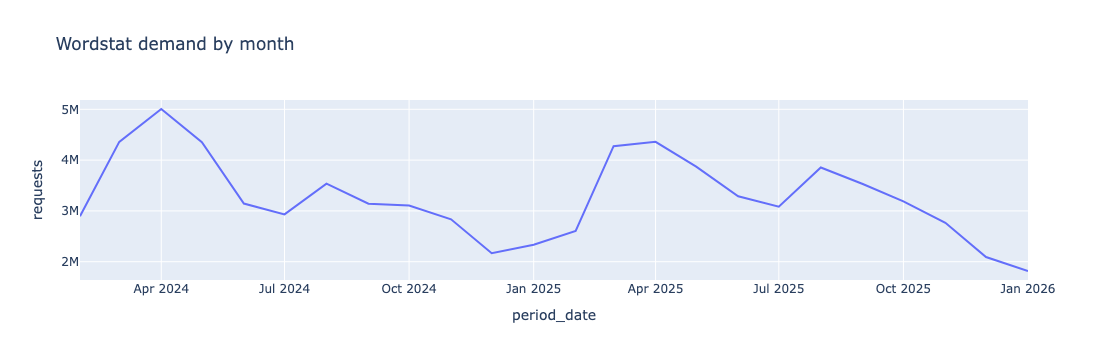

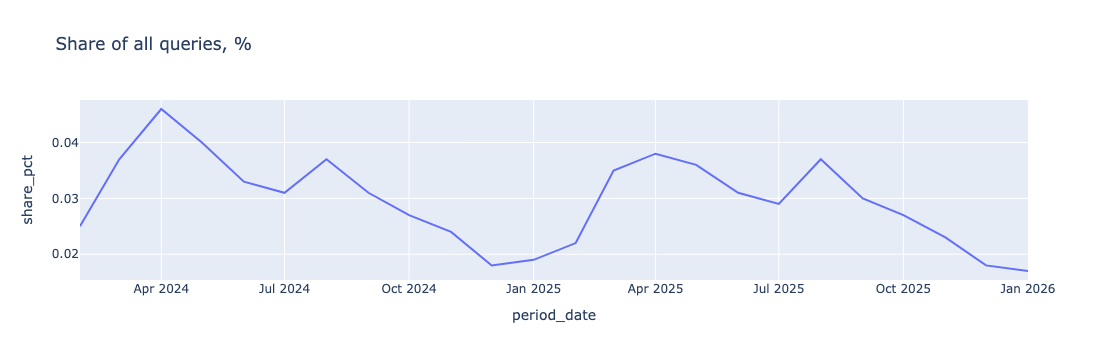

In [46]:
import pandas as pd
import plotly.express as px
import subprocess
import io
import shutil

CH = shutil.which("clickhouse")
print("clickhouse bin:", CH)

# 1) monthly dynamic
q1 = "SELECT period_date, requests, share_pct FROM wordstat.dynamic_raw ORDER BY period_date FORMAT CSVWithNames"
res1 = subprocess.check_output([CH, "client", "--query", q1], text=True)
df_dyn = pd.read_csv(io.StringIO(res1))

fig1 = px.line(df_dyn, x="period_date", y="requests", title="Wordstat demand by month")
fig1.show()

fig2 = px.line(df_dyn, x="period_date", y="share_pct", title="Share of all queries, %")
fig2.show()

### Поднимаем DataLens Open Source

### **cd /Users/macbook/Desktop**

### **git clone https://github.com/datalens-tech/datalens.git**

### **cd datalens**

### **docker compose up -d**


## Create tables using SQL

In [23]:
'''clickhouse client --multiquery --query "
CREATE DATABASE IF NOT EXISTS wordstat;

CREATE TABLE IF NOT EXISTS wordstat.product_monthly_actual
(
    product String,
    month_date Date,
    requests UInt64,
    share_pct Float64,
    loaded_at DateTime DEFAULT now()
)
ENGINE = MergeTree
ORDER BY (product, month_date);

CREATE TABLE IF NOT EXISTS wordstat.product_monthly_forecast
(
    product String,
    month_date Date,
    requests UInt64,
    model_version String,
    loaded_at DateTime DEFAULT now()
)
ENGINE = MergeTree
ORDER BY (product, month_date);
"
'''

'clickhouse client --multiquery --query "\nCREATE DATABASE IF NOT EXISTS wordstat;\n\nCREATE TABLE IF NOT EXISTS wordstat.product_monthly_actual\n(\n    product String,\n    month_date Date,\n    requests UInt64,\n    share_pct Float64,\n    loaded_at DateTime DEFAULT now()\n)\nENGINE = MergeTree\nORDER BY (product, month_date);\n\nCREATE TABLE IF NOT EXISTS wordstat.product_monthly_forecast\n(\n    product String,\n    month_date Date,\n    requests UInt64,\n    model_version String,\n    loaded_at DateTime DEFAULT now()\n)\nENGINE = MergeTree\nORDER BY (product, month_date);\n"\n'

In [24]:
'''
clickhouse client --multiquery --query "
TRUNCATE TABLE wordstat.product_monthly_actual;

INSERT INTO wordstat.product_monthly_actual (product, month_date, requests, share_pct)
SELECT
    'кроссовки' AS product,
    period_date AS month_date,
    requests,
    share_pct
FROM wordstat.dynamic_raw;
"
'''

'\nclickhouse client --multiquery --query "\nTRUNCATE TABLE wordstat.product_monthly_actual;\n\nINSERT INTO wordstat.product_monthly_actual (product, month_date, requests, share_pct)\nSELECT\n    \'кроссовки\' AS product,\n    period_date AS month_date,\n    requests,\n    share_pct\nFROM wordstat.dynamic_raw;\n"\n'

# ML Block

In [29]:
import io
import shutil
import subprocess
import pandas as pd

PRODUCT = 'кроссовки'

#find the path to the clickhouse
def ch():
    return shutil.which('clickhouse')

#Apply SQL in ClickHouse and return text as pandas.DataFrame
def query_df(sql: str):
    result = subprocess.check_output([ch(), 'client', '--query', sql], text=True)
    return pd.read_csv(io.StringIO(result))


# f"""...""" is needed to insert the value of the PRODUCT variable inside SQL.

sql = f"""
SELECT month_date, requests
FROM wordstat.product_monthly_actual
WHERE product = '{PRODUCT}'
ORDER BY month_date
FORMAT CSVWithNames
"""

df = query_df(sql)
df["month_date"] = pd.to_datetime(df["month_date"])
df["requests"] = pd.to_numeric(df["requests"], errors="coerce")
print(df.head())
print("rows:", len(df))

  month_date  requests
0 2024-02-01   2895024
1 2024-03-01   4359585
2 2024-04-01   5006077
3 2024-05-01   4352701
4 2024-06-01   3144885
rows: 24


In [36]:
import numpy as np
import math

#lags - past row values for forecasts
LAGS = 6

y = df['requests'].astype(float).values
m = df['month_date'].dt.month.values

X_train = []
y_train = []

for i in range(LAGS, len(y)):
    #lag1...lag6 last 6 values of row
    lags = y[i - LAGS:i][::-1]

    '''
    cyclical encoding in order to improve seasonality(make points december and january near, not 12 and 1)
    January (m=1):
    θ = 2π * 1/12 = π/6
    sin ≈ 0.5, cos ≈ 0.866

    June (m=6):
    θ = π
    sin = 0, cos = -1

    December (m=12):
    θ = 2π
    sin = 0, cos = 1
    '''

    sin_m = math.sin(2*math.pi*m[i]/12)
    cos_m = math.cos(2*math.pi*m[i]/12)

    #one training row which contains previous values(lags) and seasonal features
    X_train.append(np.concatenate([lags, [sin_m, cos_m]]))
    #expected result
    y_train.append(y[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape) 
print("y_train shape:", y_train.shape) 

X_train shape: (18, 8)
y_train shape: (18,)


In [40]:
pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 6.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [44]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_train_log = np.log1p(y_train) #log(1 + x)

#https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes = (32, 16),
        activation = 'tanh',
        solver = 'adam',
        random_state = 42,
        max_iter = 5000,
        early_stopping = True,
        n_iter_no_change = 30
    
    ))
])

model.fit(X_train, y_train_log)
print(model.score(X_train, y_train_log))

0.7939324988872339


In [45]:
history = list(y.astype(float))
last_month = df['month_date'].iloc[-1]
min_floor = np.percentile(y, 5) * 0.1

forecast_rows = []

for step in range(1, 13):
    #DateOffset it moves correctly by calendar months.
    future_date = last_month + pd.DateOffset(months = step)
    month_num = future_date.month

    sin_m = math.sin(2 * math.pi * month_num / 12)
    cos_m = math.cos(2 * math.pi * month_num / 12)
    
    '''
    MLPRegressor.predict() waiting for a 2D array of the shape:
    (n_samples, n_features).
    n_samples = 1 (we predict one next month),
    n_features = 8 (6 lags + sin + cos).
    '''
    
    lags = np.array(history[-LAGS:][::-1], dtype=float)
    x = np.concatenate([lags, [sin_m, cos_m]]).reshape(1, -1)

    #pred = number of predicted requests of a particular product
    pred_log = float(model.predict(x)[0])
    pred = float(np.expm1(pred_log)) #exp(x) - 1 to return from log to number
    pred = max(pred, min_floor) #avoid getting 0 or under

    history.append(pred)
    forecast_rows.append((future_date.strftime("%Y-%m-%d"), int(round(pred))))

fcst_df = pd.DataFrame(forecast_rows, columns = ['month_date', 'requests'])
print(fcst_df)
    


    month_date  requests
0   2026-02-01   2513928
1   2026-03-01   3407965
2   2026-04-01   3389684
3   2026-05-01   3411803
4   2026-06-01   3444279
5   2026-07-01   3467793
6   2026-08-01   3465310
7   2026-09-01   3426739
8   2026-10-01   3299990
9   2026-11-01   3041626
10  2026-12-01   2583502
11  2027-01-01   2168787


## **Load this progress into ClickHouse**

In [47]:
PRODUCT = 'кроссовки'
'''
mlp — neural network MLP,
lag6 — used 6 lags,
log1p — The target was log-converted,
v1 — first version.
'''
MODEL_VERSION = 'mlp_lag6_log1p_v1'

#clean previous forecast for the product
subprocess.run(
    [ch(), "client", "--query", f"ALTER TABLE wordstat.product_monthly_forecast DELETE WHERE product = '{PRODUCT}'"],
    check=True
)

#forming a TSV package
payload = "\n".join(
    f"{PRODUCT}\t{row.month_date}\t{int(row.requests)}\t{MODEL_VERSION}"
    for row in fcst_df.itertuples(index=False)
) + "\n"

#insert new forecast
subprocess.run(
    [
        ch(), "client", "--query",
        'INSERT INTO wordstat.product_monthly_forecast(product, month_date, requests, model_version) FORMAT TSV'
    ],
    input=payload.encode("utf-8"),
    check=True
)

print('forecast inserted', len(fcst_df))

forecast inserted 12


In [48]:
check_sql = """
SELECT product, month_date, requests, model_version
FROM wordstat.product_monthly_forecast
WHERE product = 'кроссовки'
ORDER BY month_date
FORMAT CSVWithNames
"""
print(query_df(check_sql).head(12))


      product  month_date  requests      model_version
0   кроссовки  2026-02-01   2513928  mlp_lag6_log1p_v1
1   кроссовки  2026-03-01   3407965  mlp_lag6_log1p_v1
2   кроссовки  2026-04-01   3389684  mlp_lag6_log1p_v1
3   кроссовки  2026-05-01   3411803  mlp_lag6_log1p_v1
4   кроссовки  2026-06-01   3444279  mlp_lag6_log1p_v1
5   кроссовки  2026-07-01   3467793  mlp_lag6_log1p_v1
6   кроссовки  2026-08-01   3465310  mlp_lag6_log1p_v1
7   кроссовки  2026-09-01   3426739  mlp_lag6_log1p_v1
8   кроссовки  2026-10-01   3299990  mlp_lag6_log1p_v1
9   кроссовки  2026-11-01   3041626  mlp_lag6_log1p_v1
10  кроссовки  2026-12-01   2583502  mlp_lag6_log1p_v1
11  кроссовки  2027-01-01   2168787  mlp_lag6_log1p_v1
